In [6]:
# create prices.csv
import requests
import pandas as pd
import os

API_KEY = os.getenv("POLYGON_API_KEY", "***REMOVED-POLYGON_API_KEY***")
BASE_URL = "https://api.polygon.io/v2/aggs/ticker/{ticker}/range/{multiplier}/{timespan}/{from_}/{to}"

def fetch_aggregates(ticker, start, end, multiplier=1, timespan="day"):
    url = BASE_URL.format(
        ticker=ticker,
        multiplier=multiplier,
        timespan=timespan,
        from_=start,
        to=end
    )
    params = {
        "adjusted": True,
        "sort": "asc",
        "limit": 50000,
        "apiKey": API_KEY
    }
    resp = requests.get(url, params=params)
    resp.raise_for_status()  # 若状态码非 200，会抛出异常
    data = resp.json()
    return data.get("results", [])

def aggs_to_dataframe(records):
    df = pd.DataFrame([{
        "date": pd.to_datetime(rec["t"], unit="ms").date(),
        "open": rec["o"],
        "high": rec["h"],
        "low":  rec["l"],
        "close":rec["c"],
        "volume":rec["v"]
    } for rec in records])
    df.set_index("date", inplace=True)
    return df

if __name__ == "__main__":
    # ① 拉取数据
    recs = fetch_aggregates("VT", "2020-01-01", "2025-07-25")
    # ② 转 DataFrame
    df = aggs_to_dataframe(recs)
    # ③ 保存为 CSV
    df.to_csv("prices.csv")
    print(f"Saved {len(df)} rows to prices.csv")

Saved 1256 rows to prices.csv


Saved 1255 rows to prices.csv
Optimal Weights:
 OrderedDict([('open', 0.28042), ('high', 0.38079), ('low', 0.0), ('close', 0.33746), ('volume', 0.00133)])
Expected annual return: 10.9%
Annual volatility: 13.3%
Sharpe Ratio: 0.82


C:\Users\Bangcheng Li\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scs\__init__.py:96: UserWarning: Converting A to a CSC (compressed sparse column) matrix; may take a while.
  warn(
C:\Users\Bangcheng Li\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scs\__init__.py:126: UserWarning: Converting P to a CSC (compressed sparse column) matrix; may take a while.
  warn(


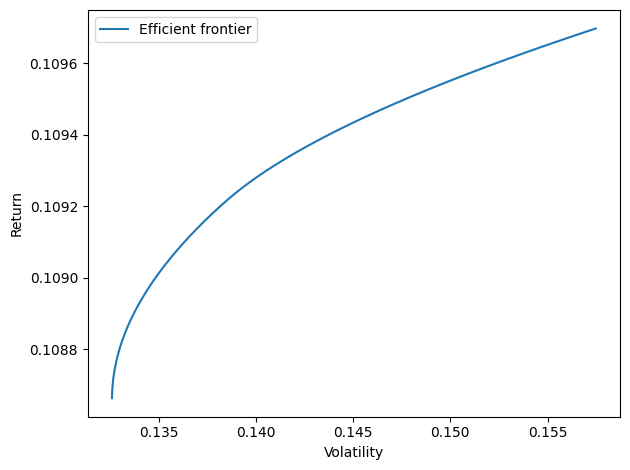

In [10]:
# create prices.csv
import requests
import pandas as pd
import os

API_KEY = os.getenv("POLYGON_API_KEY", "***REMOVED-POLYGON_API_KEY***")
BASE_URL = "https://api.polygon.io/v2/aggs/ticker/{ticker}/range/{multiplier}/{timespan}/{from_}/{to}"

def fetch_aggregates(ticker, start, end, multiplier=1, timespan="day"):
    url = BASE_URL.format(
        ticker=ticker,
        multiplier=multiplier,
        timespan=timespan,
        from_=start,
        to=end
    )
    params = {
        "adjusted": True,
        "sort": "asc",
        "limit": 50000,
        "apiKey": API_KEY
    }
    resp = requests.get(url, params=params)
    resp.raise_for_status()  # 若状态码非 200，会抛出异常
    data = resp.json()
    return data.get("results", [])

def aggs_to_dataframe(records):
    df = pd.DataFrame([{
        "date": pd.to_datetime(rec["t"], unit="ms").date(),
        "open": rec["o"],
        "high": rec["h"],
        "low":  rec["l"],
        "close":rec["c"],
        "volume":rec["v"]
    } for rec in records])
    df.set_index("date", inplace=True)
    return df

if __name__ == "__main__":
    # ① 拉取数据
    recs = fetch_aggregates("VT", "2020-01-01", "2025-07-25")
    # ② 转 DataFrame
    df = aggs_to_dataframe(recs)
    # ③ 保存为 CSV
    df.to_csv("prices.csv")
    print(f"Saved {len(df)} rows to prices.csv")

# Sharpe, Return, and Volatility
import pandas as pd
from pypfopt import expected_returns, risk_models, EfficientFrontier, plotting

# 1. 准备数据：假设 df 是包含多只股票收盘价的 DataFrame
df = pd.read_csv("prices.csv", parse_dates=True, index_col="date")

# 2. 计算预期收益与风险模型
mu = expected_returns.mean_historical_return(df)          # 历史平均收益
S  = risk_models.sample_cov(df)                           # 样本协方差

# 3. 均值–方差优化：最大化夏普比率
ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe()                                  # 获取最优权重
cleaned_weights = ef.clean_weights()                       # 清洗 (去除小于阈值的权重)
print("Optimal Weights:\n", cleaned_weights)

# 4. 输出性能指标
performance = ef.portfolio_performance(verbose=True)
# 比如：
# Expected annual return: 12.5%
# Annual volatility: 9.8%
# Sharpe Ratio: 1.27

# 5. 可视化有效前沿
ef_for_plot = EfficientFrontier(mu, S, solver='SCS')
ax = plotting.plot_efficient_frontier(ef_for_plot, show_assets=False)


In [27]:
import os
import json
import pandas as pd
import requests
import ast
import time
from tqdm import tqdm
from openai import OpenAI
from pypfopt import expected_returns, risk_models, EfficientFrontier
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

# === 全局配置 ===
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "***REMOVED-OPENAI_API_KEY***")  # 从环境变量读取 OpenAI Key
POLYGON_API_KEY = os.getenv("POLYGON_API_KEY", "***REMOVED-POLYGON_API_KEY***")  # 从环境变量读取 Polygon Key
BASE_URL = (
    "https://api.polygon.io/v2/aggs/ticker/{ticker}/range/"
    "{multiplier}/{timespan}/{from_}/{to}"
)

# === 进度打印辅助 ===
def print_step(step, total_steps, description):
    print(f"[{step}/{total_steps}] {description}")

# === 1. 调用 OpenAI 生成组合权重 ===
def generate_portfolios():
    client = OpenAI(api_key=OPENAI_API_KEY)
    prompt = f"""
You are an expert portfolio construction advisor.
Based on the past year of US stock performance, generate 3 portfolio suggestions:
1. max_sharpe
2. medium (balanced)
3. min_volatility

Output must be a pure JSON list, each element containing 'name' and 'weights' mappings.
DO NOT include any explanation or extra text.
"""
    resp = client.chat.completions.create(
        model="gpt-4o", messages=[{"role": "user", "content": prompt}]
    )
    raw = resp.choices[0].message.content
    txt_path = os.path.join("D:/my-fin-project/txt_save", "portfolios.txt")
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(raw)
    print("原始组合已保存到 txt_save/portfolios.txt")
    return clean_portfolios_txt(txt_path)

# === 2. 清洗 GPT 输出，保存 JSON ===
def clean_portfolios_txt(txt_file, json_file=None):
    with open(txt_file, "r", encoding="utf-8") as f:
        lines = f.readlines()
    # Remove potential wrapping lines
    if len(lines) > 2:
        lines = lines[1:-1]
    content = "".join(lines).strip()
    try:
        data = json.loads(content)
    except json.JSONDecodeError:
        data = ast.literal_eval(content)
    # Save cleaned JSON
    if not json_file:
        json_file = os.path.join("D:/my-fin-project/json_save", "portfolios.json")
    with open(json_file, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print(f"Cleaned portfolios saved to json_save/{os.path.basename(json_file)}")
    return data

# === 3. 从 JSON 中提取三种风险等级的权重字典 ===
def load_portfolios(json_file=None):
    if not json_file:
        json_file = os.path.join("D:/my-fin-project/json_save", "portfolios.json")
    data = json.load(open(json_file, "r", encoding="utf-8"))
    high = next((p["weights"] for p in data if 'max_sharpe' in p['name'].lower() or 'high' in p['name'].lower()), {})
    medium = next((p["weights"] for p in data if 'medium' in p['name'].lower() or 'balanced' in p['name'].lower()), {})
    low = next((p["weights"] for p in data if 'min_volatility' in p['name'].lower() or 'low' in p['name'].lower()), {})
    return high, medium, low

# === 4. 拉取行情并保存宽表 CSV ===
def fetch_and_save(tickers, start, end, filename, multiplier=1, timespan="day"):  
    records = []
    for t in tqdm(tickers, desc="Fetching data"):
        url = BASE_URL.format(ticker=t, multiplier=multiplier, timespan=timespan, from_=start, to=end)
        params = {"adjusted": True, "sort": "asc", "limit": 50000, "apiKey": POLYGON_API_KEY}
        resp = requests.get(url, params=params); resp.raise_for_status()
        for item in resp.json().get("results", []):
            records.append({
                "date": pd.to_datetime(item["t"], unit="ms"),
                "ticker": t,
                "close": item["c"]
            })
    df = pd.DataFrame(records).pivot(index="date", columns="ticker", values="close")
    path = os.path.join("D:/my-fin-project/csv_save", filename)
    df.to_csv(path)
    print(f"行情数据已保存到 csv_save/{filename}")
    return path

# === 5. 绩效分析 + 离散配股 ===
def analyze_performance(csv_file, weights, total_value):
    df = pd.read_csv(csv_file, parse_dates=True, index_col="date")
    mu = expected_returns.mean_historical_return(df)
    S = risk_models.sample_cov(df)
    ef = EfficientFrontier(mu, S)
    # 指定自定义权重并计算绩效
    ef.weights = weights
    ret, vol, sharpe = ef.portfolio_performance(verbose=True)
    latest = get_latest_prices(df)
    da = DiscreteAllocation(weights, latest, total_portfolio_value=total_value)
    alloc, leftover = da.greedy_portfolio()
    print(f"Discrete allocation: {alloc}")
    print(f"Funds remaining: ${leftover:.2f}")
    return ret, vol, sharpe, alloc, leftover

# === 6. 主流程 ===
def run_pipeline(start="2024-07-25", end="2025-07-25", total_value=10000):
    steps = 2 + 3 * 3
    s = 1; t0 = time.time()
    print_step(s, steps, "生成组合权重 via AI"); portfolios = generate_portfolios(); s+=1
    print_step(s, steps, "加载组合 JSON"); high, med, low = load_portfolios(); s+=1
    results = []
    for level, w in [("high", high), ("medium", med), ("low", low)]:
        print_step(s, steps, f"拉取 {level} 组合行情"); csvp = fetch_and_save(list(w.keys()), start, end, f"{level}_portfolio.csv"); s+=1
        print_step(s, steps, f"分析 {level} 组合绩效"); perf = analyze_performance(csvp, weights=w, total_value=total_value); s+=1
        print_step(s, steps, f"保存 {level} 组合结果");
        ret, vol, sharpe, alloc, _ = perf
        out = {"risk_level": level, "tickers": list(w.keys()), "allocation": alloc,
               "exp_return": ret, "volatility": vol, "sharpe": sharpe}
        outf = os.path.join("D:/my-fin-project/output_save", f"{level}_performance.json")
        with open(outf, "w", encoding="utf-8") as f: json.dump(out, f, ensure_ascii=False, indent=2)
        print(f"已保存结果到 output_save/{level}_performance.json")
        results.append(out)
        s+=1
    print(f"Pipeline 完成：{time.time()-t0:.2f}s")
    return results

# === 入口 ===
if __name__ == "__main__":
    all_res = run_pipeline()
    print("所有组合结果：", all_res)


[1/11] 生成组合权重 via AI
原始组合已保存到 txt_save/portfolios.txt
Cleaned portfolios saved to json_save/portfolios.json
[2/11] 加载组合 JSON
[3/11] 拉取 high 组合行情


Fetching data: 100%|██████████| 7/7 [00:06<00:00,  1.08it/s]

行情数据已保存到 csv_save/high_portfolio.csv
[4/11] 分析 high 组合绩效


ValueError: Weights add to zero, or ticker names don't match

In [20]:
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

df = pd.read_csv("D:\my-fin-project\csv_save\high_portfolio.csv", parse_dates=["date"], index_col="date")
latest_prices = get_latest_prices(df)

print("Index name:", df.index.name)
print("Columns:", df.columns.tolist())

Index name: date
Columns: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']


In [21]:
latest_prices = get_latest_prices(df)
print("Latest prices dict:", latest_prices)

Latest prices dict: AAPL    213.88
AMZN    231.44
MSFT    513.71
NVDA    173.50
TSLA    316.06
Name: 2025-07-25 04:00:00, dtype: float64


In [22]:
print("Weights keys:", weights.keys())
# 结果应该是 dict_keys(['AAPL','AMZN','MSFT','NVDA','TSLA'])


Weights keys: odict_keys(['open', 'high', 'low', 'close', 'volume'])


In [ ]:
da = DiscreteAllocation(weights, latest_prices, total_portfolio_value=10000)
allocation, leftover = da.greedy_portfolio()
print("Discrete allocation:", allocation)
print("Funds remaining: ${:.2f}".format(leftover))